# Import Liblary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import & prapemerosesan data

**import data**

In [2]:
health_df = pd.read_csv('data/heart_statlog_cleveland_hungary_final.csv')
health_df

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1185,45,1,1,110,264,0,0,132,0,1.2,2,1
1186,68,1,4,144,193,1,0,141,0,3.4,2,1
1187,57,1,4,130,131,0,0,115,1,1.2,2,1
1188,57,0,2,130,236,0,2,174,0,0.0,2,1


In [3]:
# analisa deskriptif data
health_df.describe()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


**Pramemerosesan data**

In [4]:
# info data
health_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


In [5]:
# cek missing value pada data
health_df.isnull().sum()

age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64

**pramerosesan data duplikat**

In [6]:
# cek duplikasi data
health_df.duplicated().sum()

np.int64(272)

In [7]:
df = pd.read_csv("data/heart_statlog_cleveland_hungary_final.csv")
duplikat = df[df.duplicated()]
print(duplikat)

      age  sex  chest pain type  resting bp s  cholesterol  \
163    49    0                2           110          208   
604    58    1                3           150          219   
887    63    1                1           145          233   
888    67    1                4           160          286   
889    67    1                4           120          229   
...   ...  ...              ...           ...          ...   
1156   42    1                3           130          180   
1157   61    1                4           140          207   
1158   66    1                4           160          228   
1159   46    1                4           140          311   
1160   71    0                4           112          149   

      fasting blood sugar  resting ecg  max heart rate  exercise angina  \
163                     0            0             160                0   
604                     0            1             118                1   
887                     1     

In [8]:
jumlah_duplikat = df.duplicated(subset=['age', 'sex', 'cholesterol']).sum()
print("Jumlah duplikat berdasarkan kolom:", jumlah_duplikat)

Jumlah duplikat berdasarkan kolom: 434


In [9]:
health_df = df.drop_duplicates(subset=['age', 'sex', 'cholesterol'])

In [10]:
health_df = df.drop_duplicates(keep=False)

In [11]:
health_df = df.drop_duplicates(ignore_index=True)

In [12]:
# cek duplikasi data
health_df.duplicated().sum()

np.int64(0)

In [13]:
# unji interaksi fitur
df['pulse_pressure'] = df['resting bp s'] - df['oldpeak']
df['heart_risk'] = df['max heart rate'] / (df['age'] + 1)

In [14]:
# Imputasi
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
df['cholesterol'] = imputer.fit_transform(df[['cholesterol']])

# Visualisasi data

<Axes: xlabel='age', ylabel='Count'>

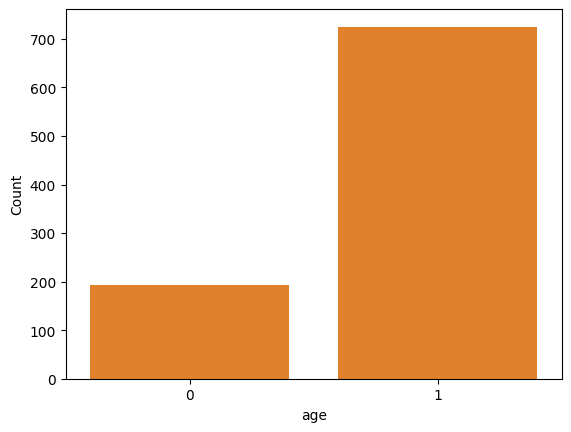

In [15]:
# Eksplorasi Demografis & Distribusi
sns.histplot(df['age'], kde=True)
sns.countplot(x='sex', data=health_df)

**Visualisasi Eksplorasi Demografis & Distribusi**
- Kategori "0" (merepresentasikan usia muda) memiliki sekitar 200 sampel.
- Kategori "1" (usia dewasa atau lebih tua) memiliki sekitar 700 sampel.

<Axes: xlabel='target', ylabel='cholesterol'>

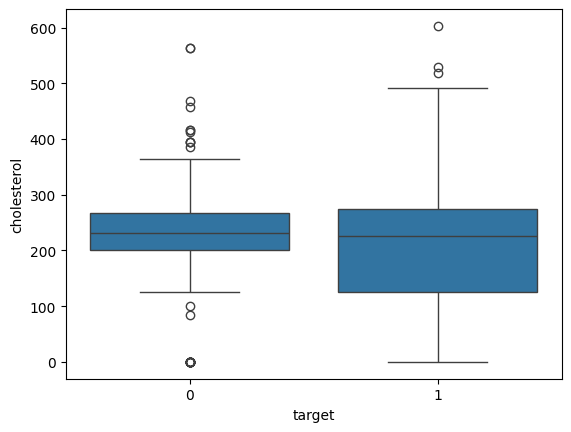

In [16]:
# Gejala Klinis & Karakteristik Jantung
sns.boxplot(x='target', y='cholesterol', data=df)

**Detail Statistik:**
- **Kelompok “0”**
  - Median kolesterol: sedikit di bawah 250
  - Rentang IQR cukup lebar dengan outlier di atas 400 dan di bawah 100
- **Kelompok “1”**
  - Median kolesterol: sedikit di atas 250
  - Outlier lebih ekstrem: hingga di atas 500, menunjukkan variabilitas lebih tinggi

**Interpretasi Awal:**
- Kedua kelompok punya median kolesterol yang mirip, tapi:
  - Kelompok “1” cenderung memiliki outlier lebih tinggi, bisa jadi menunjukkan risiko kesehatan yang lebih besar.
  - Distribusi pada kelompok “1” juga tampak lebih menyebar → potensi heterogenitas dalam kelompok ini.

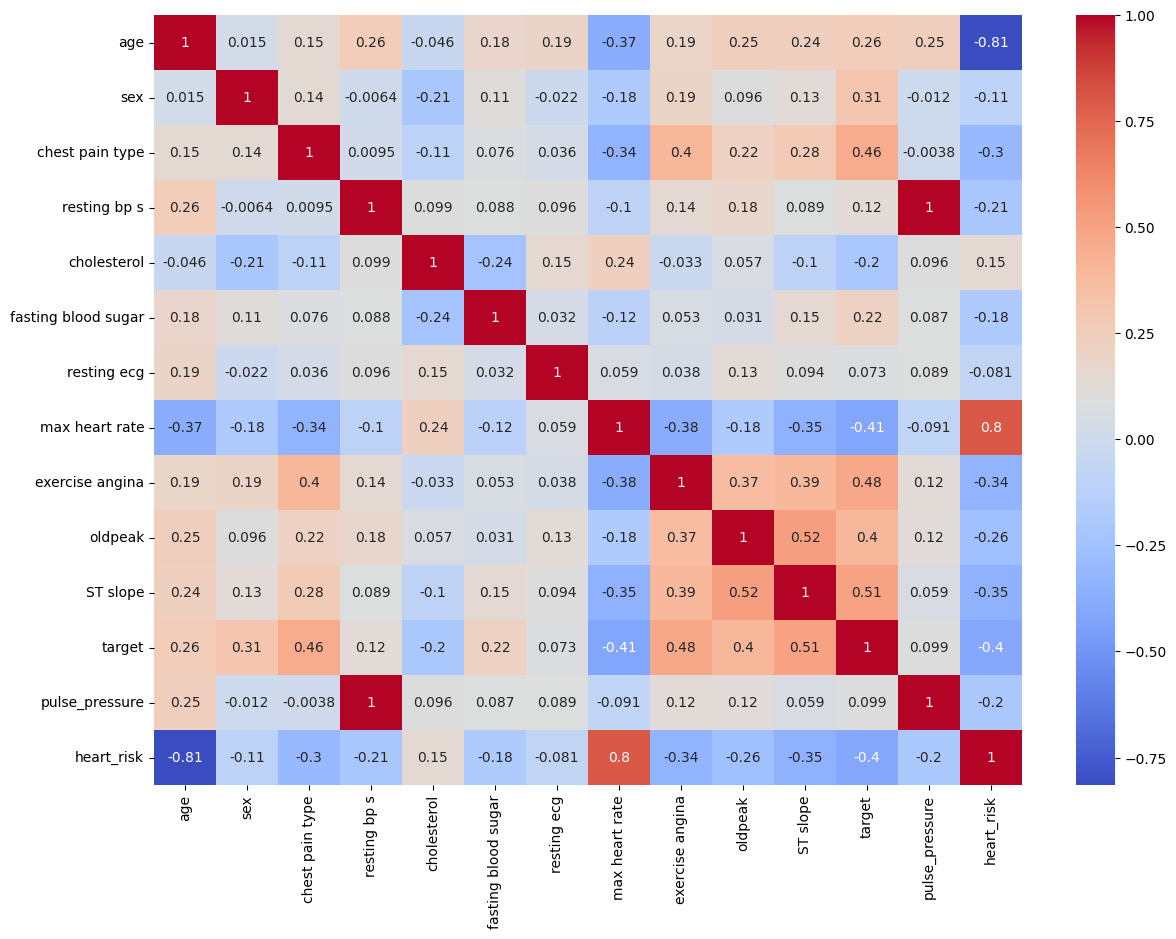

In [17]:
# Korelasi dengan Target
corr_matrix = df.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

**Komentar visualisasi data**

**Observasi Kunci:**
- **Korelasi kuat positif:**
  - chest pain type dengan target: ~0.42 → jenis nyeri dada sangat berpengaruh terhadap diagnosis.
  - ST slope dengan target: ~0.36 → perubahan segmen ST pada EKG sangat relevan.

- **Korelasi negatif yang signifikan:**
  - exercise angina vs target: ~-0.44 → angina saat latihan justru menurunkan peluang diagnosis positif (bisa jadi karena tipe target).
  - oldpeak vs target: ~-0.43 → semakin tinggi depresi ST, semakin kecil kemungkinan diagnosis positif.

- **Korelasi lemah atau mendekati nol:**
  - cholesterol, resting blood pressure, fasting blood sugar → kontribusi rendah dalam prediksi, mungkin butuh teknik feature engineering lanjutan.

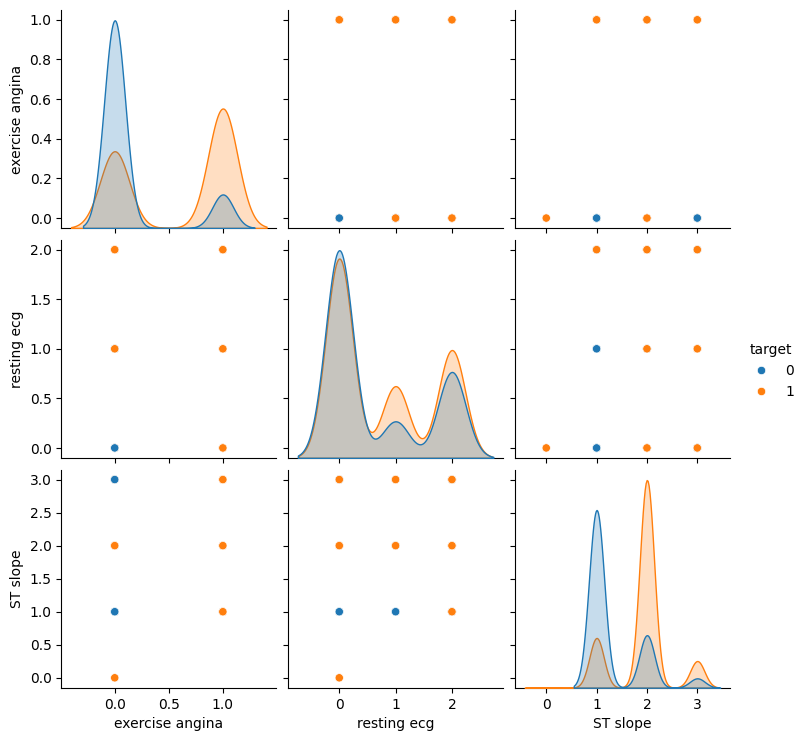

In [18]:
# Aktivitas & ECG
sns.pairplot(df, vars=['exercise angina', 'resting ecg', 'ST slope'], hue='target')

**Komentar visualisasi data**

<Axes: xlabel='target', ylabel='oldpeak'>

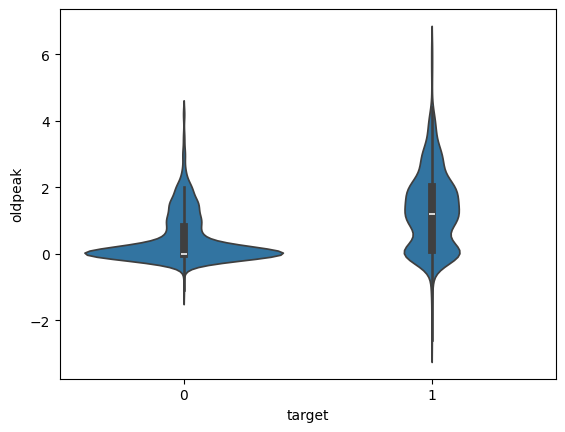

In [19]:
sns.violinplot(x='target', y='oldpeak', data=df)

<Axes: xlabel='cholesterol', ylabel='Count'>

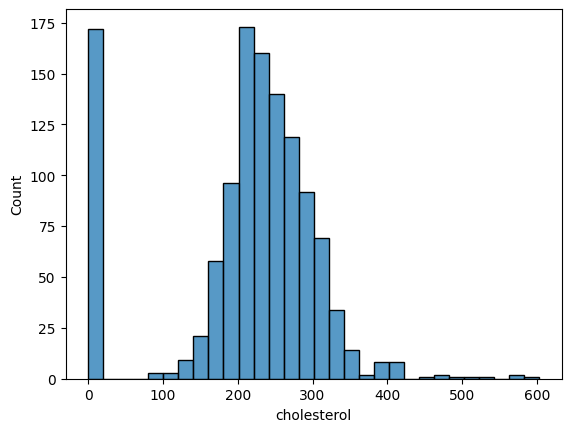

In [20]:
import seaborn as sns
sns.histplot(df['cholesterol'], bins=30)

**Komentar visualisasi data**

# Buat & evaluasi model

In [21]:
X = df.drop('target', axis=1)
y = df['target']

In [22]:
# membagi data latih dan data uji
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
# Scaling Data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

# parameters
param_distributions = {
    'rf__n_estimators': np.arange(100, 300, 50),
    'rf__max_depth': [1, 5, 10, 15],  
    'rf__min_samples_leaf': np.arange(2, 10, 1),
    'rf__min_samples_split': np.arange(5, 20, 2),
    'rf__max_features': ['sqrt', 'log2', 0.5, 0.7],
    'rf__min_impurity_decrease': [0.0, 0.01, 0.005]
}

random_search = RandomizedSearchCV(estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=100,
    cv=10,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42)

random_search.fit(X_train, y_train)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits


**evaluasi model**

In [ ]:
print("Hasil RandomizedSearchCV:")
print(f"Parameter Terbaik: {random_search.best_params_}")
print(f"Skor Cross-Validation Terbaik: {random_search.best_score_:.4f}")

best_model = random_search.best_estimator_
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

# Hitung akurasi pada data latih dan data uji
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("\nEvaluasi Model AI/Machine Learning Terbaik:")
print(f"Akurasi Data Latih: {train_accuracy:.4f}%")
print(f"Akurasi Data Uji: {test_accuracy:.4f}%")

Hasil RandomizedSearchCV:
Parameter Terbaik: {'rf__n_estimators': np.int64(150), 'rf__min_samples_split': np.int64(7), 'rf__min_samples_leaf': np.int64(3), 'rf__min_impurity_decrease': 0.0, 'rf__max_features': 'log2', 'rf__max_depth': 10}
Skor Cross-Validation Terbaik: 0.8949

Evaluasi Model AI/Machine Learning Terbaik:
Akurasi Data Latih: 0.9527%
Akurasi Data Uji: 0.9160%


In [ ]:
from sklearn.metrics import accuracy_score

# Prediksi untuk train dan test set
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

# Hitung dan tampilkan akurasi dalam persentase
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"Train Accuracy (tuned model): {train_acc * 100:.2f}%")
print(f"Test Accuracy (tuned model): {test_acc * 100:.2f}%")    

Train Accuracy (tuned model): 95.27%
Test Accuracy (tuned model): 91.60%


In [ ]:
# laporan hasil klasifikasi
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_test))
print("acuraty", accuracy_score(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.94      0.87      0.90       107
           1       0.90      0.95      0.93       131

    accuracy                           0.92       238
   macro avg       0.92      0.91      0.91       238
weighted avg       0.92      0.92      0.92       238

acuraty 0.9159663865546218


In [ ]:
# Cross-validation (misalnya 5-fold CV)
from sklearn.model_selection import cross_val_score
scores = cross_val_score(best_model, X, y, cv=5)
print("Scores:", scores)
print("Mean Accuracy:", scores.mean())  

Scores: [0.89915966 0.8697479  0.92016807 0.87815126 0.90756303]
Mean Accuracy: 0.8949579831932774


**Visualisasi hasil model random forest**

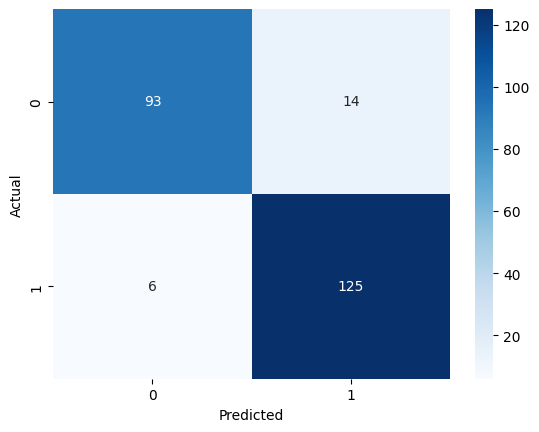

In [ ]:
# visualisasi matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.model_selection import learning_curve
best_model = random_search.best_estimator_

# Menghitung learning curve
train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_model,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Hitung rata-rata dan standar deviasi
train_scores_mean = train_scores.mean(axis=1)
train_scores_std = train_scores.std(axis=1)
test_scores_mean = test_scores.mean(axis=1)
test_scores_std = test_scores.std(axis=1)

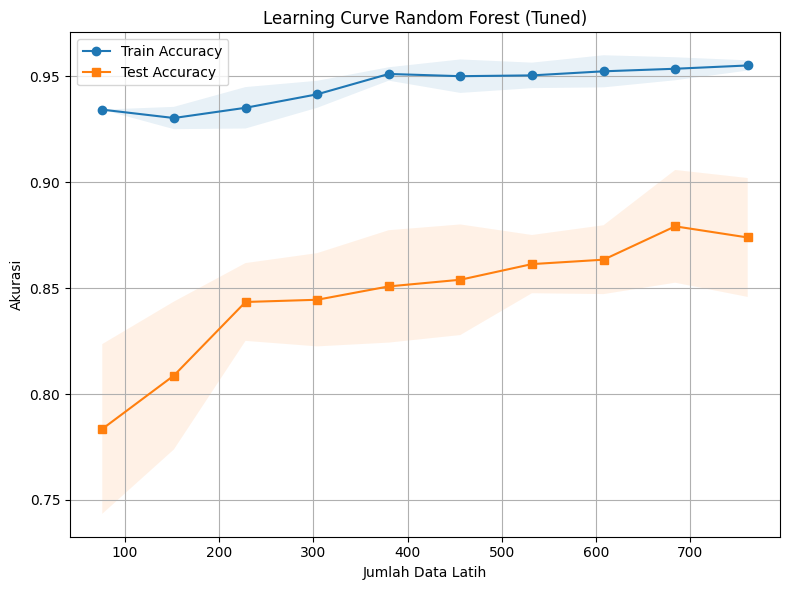

In [ ]:
# Plot learning curve
plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_scores_mean, label='Train Accuracy', marker='o')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1)
plt.plot(train_sizes, test_scores_mean, label='Test Accuracy', marker='s')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1)
plt.title('Learning Curve Random Forest (Tuned)')
plt.xlabel('Jumlah Data Latih')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Pengujian pada data unseen**

In [ ]:
X_full_train, X_unseen, y_full_train, y_unseen = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
random_search.fit(X_full_train, y_full_train)
best_model = random_search.best_estimator_

Fitting 10 folds for each of 100 candidates, totalling 1000 fits


Akurasi pada data unseen: 0.9034
              precision    recall  f1-score   support

           0       0.89      0.90      0.90       112
           1       0.91      0.90      0.91       126

    accuracy                           0.90       238
   macro avg       0.90      0.90      0.90       238
weighted avg       0.90      0.90      0.90       238



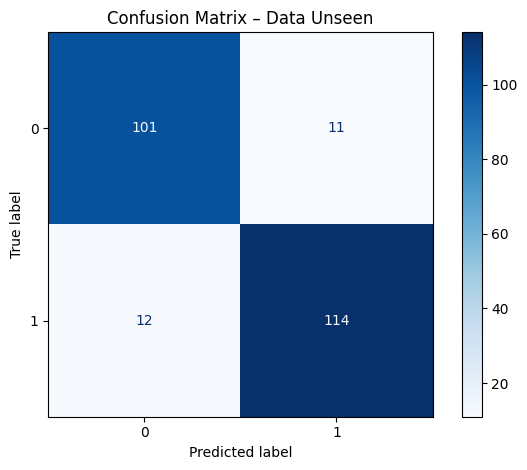

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Prediksi
y_pred_unseen = best_model.predict(X_unseen)

# Akurasi
acc_unseen = accuracy_score(y_unseen, y_pred_unseen)
print(f"Akurasi pada data unseen: {acc_unseen:.4f}")

# Laporan klasifikasi
print(classification_report(y_unseen, y_pred_unseen))

# Visualisasi confusion matrix
ConfusionMatrixDisplay.from_predictions(y_unseen, y_pred_unseen, cmap='Blues')
plt.title('Confusion Matrix – Data Unseen')
plt.tight_layout()
plt.show()

# Menyimpan Model Machine Learning

In [ ]:
# menyimpan model machine learning dengan joblib
import joblib
joblib.dump(best_model, 'best_model.joblib')
joblib.load('best_model.joblib')

,steps,"[('scaler', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,np.int64(150)
,criterion,'gini'
,max_depth,10
,min_samples_split,np.int64(7)
